In [20]:
from langgraph.graph import StateGraph, MessageGraph
from typing import TypedDict, Annotated

In [2]:
import os
from dotenv import load_dotenv
load_dotenv(override=True)

True

In [66]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
import os
from langchain_google_genai import ChatGoogleGenerativeAI

In [123]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings
embeddings=GoogleGenerativeAIEmbeddings(model="models/text-embedding-004")
from langchain_google_genai import ChatGoogleGenerativeAI
llm=ChatGoogleGenerativeAI(model="gemini-3-flash-preview")
   

In [8]:
llm.invoke("Hello, Where did Sachin Tendulkar make his second test century?").content

AIMessage(content=[{'type': 'text', 'text': 'Sachin Tendulkar made his second Test century at the **Sydney Cricket Ground (SCG)** in Australia.\n\nHe scored **148 not out** against Australia in January 1992. This innings was particularly significant as he became the youngest batsman to score a Test century in Australia, at the age of 18.', 'extras': {'signature': 'EtcFCtQFAQw51scWH4tY2lHHnrGVOij8u79JTe9xTtt/mraanStj5fBsUaWjLGgJ6oaHATyfJ7tvsc2d1RpGZGb0UsxjkHb5fXCUcDOLgNfCKlnOuaOuBgsD86gND4HmIu6XGNa08HkO76f88REKh+9MzrRpy8UOO/IPK5GdCbxEIOaU4xNyLHb2kLf//k9w9T6v+tRXddMqnhD0Ir8BxbOqdKUEQq/fu4uhhTtPvCr/i5Gh6mkDmpvmT34SHIl+yaMcubWW8vuxnv2BaMGwQdN52dWhaISs0sHPOI473DXNjTHxl1fWvHnAYCETh7UnkO/jrTsgGXctoBNvV8eK/Srih4SgLvaMxbtgcfTzk5E8hNAPifaIK7RYwsWdy64epFyky3b4l+eydNi0RX9VqYeWNMasUJMmG87eATV12acq34Zxc3Kiu5cldgOINh6w6uRQXovT2GVFpr4yMGsSB2Q08r0+mwfiVztScPT0jJO1g8FlfEE0rYKHGsODdDLWcaN0Dgzasb7kTCHQ028I6KzaizV4d5ksCxnSmdQGk912TMY+Ai3vHQBYHuXUqOP1fvtbxfVe4Tj7YciiukSmnYdUihWD7CJz/VjJb4MBlUv3XS523s4B2jDRS

In [97]:
class GraphState(TypedDict):
    messages: list

def LLM(state: GraphState):
    user_input = state["messages"][-1]
    
    # We use the 'version' argument directly. 
    # Also, ensure 'gemini' is spelled correctly.
    llm = ChatGoogleGenerativeAI(
        model="gemini-3-flash-preview", 
        version="v1", 
        google_api_key=os.getenv("GOOGLE_API_KEY")
    )
    
    response = llm.invoke(user_input).content
    return {"messages": state["messages"] + [response]}

def Counter_Token(state: GraphState):
    # 1. Access the list of messages
    message_list = state["messages"]
    
    # 2. Grab the VERY LAST message (the LLM's response)
    # Using [-1] ensures we get the string, not the whole list
    last_response = message_list[-1]
    
    # 3. Now .split() will work because last_response is a string
    token_count = len(last_response.split())
    msg = f"Total number of tokens is {token_count}"
    
    # 4. Return the dictionary to update the state
    return {"messages": state["messages"] + [msg]}

In [98]:
workflow = StateGraph(GraphState)

In [99]:
workflow.add_node("My LLM",LLM)


In [100]:
workflow.add_node("Token Counter",Counter_Token)


In [101]:
workflow.add_edge(START, "My LLM")
workflow.add_edge("My LLM", "Token Counter")
workflow.add_edge("Token Counter", END)

In [102]:
app=workflow.compile()

In [103]:
from IPython.display import display,Image

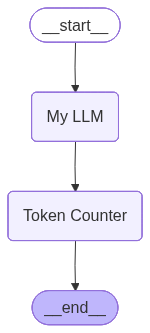

In [104]:
display(Image(app.get_graph().draw_mermaid_png()))

In [109]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
import operator
import os
from langchain_google_genai import ChatGoogleGenerativeAI

# 1. Define State with a Reducer (This is the "Secret Sauce")
# Annotated + operator.add tells LangGraph to ALWAYS append to the list
class GraphState(TypedDict):
    messages: Annotated[list, operator.add]

# 2. Define Nodes
def LLM(state: GraphState):
    # state["messages"] is a list, we take the last string
    user_input = state["messages"][-1]
    
    llm = ChatGoogleGenerativeAI(model="gemini-3-flash-preview")
    
    # Get the response and force it to a string
    response = llm.invoke(user_input)
    response_text = str(response.content) 
    
    # Return as a list so operator.add can append it
    return {"messages": [response_text]}

def Counter_Token(state: GraphState):
    # Grab the last item. We add a check to make sure it's a string.
    last_item = state["messages"][-1]
    
    # If for some reason last_item is still a list, join it into a string
    if isinstance(last_item, list):
        last_item = " ".join(map(str, last_item))
    
    # Now .split() is 100% safe
    token_count = len(str(last_item).split())
    msg = f"Total number of tokens is {token_count}"
    
    return {"messages": [msg]}

# 3. Build Workflow
# Re-initializing here is mandatory to apply the new Annotated State
workflow = StateGraph(GraphState)

workflow.add_node("My LLM", LLM)
workflow.add_node("Token Counter", Counter_Token)

workflow.add_edge(START, "My LLM")
workflow.add_edge("My LLM", "Token Counter")
workflow.add_edge("Token Counter", END)

app = workflow.compile()

# 4. Run
input_dict = {"messages": ["Explain me in a detailed manner what is AGENTIC AI"]}
result = app.invoke(input_dict)

# 5. Display
print("--- FULL CONVERSATION ---")
for m in result["messages"]:
    print(f"\n>> {m}")

--- FULL CONVERSATION ---

>> Explain me in a detailed manner what is AGENTIC AI

>> [{'type': 'text', 'text': 'To understand **Agentic AI**, you first need to distinguish it from the AI we have been using for the past few years (like standard ChatGPT or Claude).\n\nWhile traditional Generative AI is like a **highly knowledgeable consultant** who gives you advice, Agentic AI is like a **highly capable employee** who can actually do the work for you.\n\nHere is a detailed breakdown of what Agentic AI is, how it works, and why it represents the next frontier of technology.\n\n---\n\n### 1. The Definition: What is "Agency"?\nIn philosophy and sociology, "agency" is the capacity of an actor to act in a given environment. \n\n**Agentic AI** refers to AI systems that are not just designed to predict the next word in a sentence, but to **independently pursue goals.** Instead of waiting for a human to provide a step-by-step prompt, an Agentic system is given a "high-level objective" (e.g., "Re

In [111]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_community.document_loaders import TextLoader,DirectoryLoader
from langchain_community.vectorstores import Chroma
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [119]:
loader_kwargs = {'encoding': 'utf-8'}
loader=DirectoryLoader("../data",glob="./*.txt",loader_cls=TextLoader,loader_kwargs=loader_kwargs)
docs=loader.load()
text_splitter=RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=200
)
new_docs = text_splitter.split_documents(documents=docs)
doc_strings = [doc.page_content for doc in new_docs]

In [133]:
embeddings = GoogleGenerativeAIEmbeddings(
    model="models/gemini-embedding-001", # This replaces the old text-embedding-004
    google_api_key=os.getenv("GOOGLE_API_KEY")
)

In [134]:
db = Chroma.from_documents(new_docs, embeddings)

retriever = db.as_retriever(search_kwargs={"k": 3})

In [136]:
db = Chroma.from_documents(new_docs, embeddings)

retriever = db.as_retriever(search_kwargs={"k": 3})

query = "why scientist was working hard for what kind of vaccines?"

docs = retriever.invoke(query)
print(docs[0].metadata)
print(docs[0].page_content)

{'source': '..\\data\\state_of_the_union.txt'}
The scientists are working hard to get that done and we’ll be ready with plenty of vaccines when they do. 

We’re also ready with anti-viral treatments. If you get COVID-19, the Pfizer pill reduces your chances of ending up in the hospital by 90%.  

We’ve ordered more of these pills than anyone in the world. And Pfizer is working overtime to get us 1 Million pills this month and more than double that next month.


In [137]:
for doc in docs:
    print(doc)

page_content='The scientists are working hard to get that done and we’ll be ready with plenty of vaccines when they do. 

We’re also ready with anti-viral treatments. If you get COVID-19, the Pfizer pill reduces your chances of ending up in the hospital by 90%.  

We’ve ordered more of these pills than anyone in the world. And Pfizer is working overtime to get us 1 Million pills this month and more than double that next month.' metadata={'source': '..\\data\\state_of_the_union.txt'}
page_content='The scientists are working hard to get that done and we’ll be ready with plenty of vaccines when they do. 

We’re also ready with anti-viral treatments. If you get COVID-19, the Pfizer pill reduces your chances of ending up in the hospital by 90%.  

We’ve ordered more of these pills than anyone in the world. And Pfizer is working overtime to get us 1 Million pills this month and more than double that next month.' metadata={'source': '..\\data\\state_of_the_union.txt'}
page_content='The scient

In [ ]:
## AGENTS

In [138]:
AgentState={}

In [147]:
AgentState["messages"]=[]

In [150]:
AgentState["messages"].append("hi")

In [151]:
AgentState["messages"].append("how are you?")

In [152]:
AgentState["messages"].append("what are you doing?")

In [153]:
# We are flowing this state across the different different nodes inside the langgraph workflow
AgentState

{'messages': ['hi', 'how are you?', 'what are you doing?']}

In [159]:
def function_1(state: GraphState):
    message=state["messages"]
    
    question=message[-1]
    
    complete_prompt="Your task is to provide only the brief answer based on the user query. \
        Don't include too much reasoning. Following is the user query: " + question
    
    response = llm.invoke(complete_prompt)

    
    return {"messages": [response.content]}
   


In [160]:
def function_2(state: GraphState):
    messages = state['messages']
    
    question = messages[0] ## Fetching the user question
    
    template = """Answer the question based only on the following context:
    {context}

    Question: {question}
    """
    prompt = ChatPromptTemplate.from_template(template)

    retrieval_chain = (
        {"context": retriever, "question": RunnablePassthrough()}
        | prompt
        | llm
        | StrOutputParser()
        )
    result = retrieval_chain.invoke(question)
    return {"messages": [result]}

In [161]:
workflow=StateGraph(GraphState)
workflow.add_node("LLM", function_1)
workflow.add_node("RAGtool", function_2)
workflow.add_edge('LLM', 'RAGtool')
workflow.set_entry_point("LLM")
workflow.set_finish_point("RAGtool")
app2 = workflow.compile()

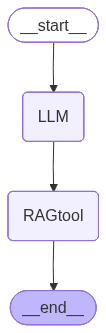

In [162]:
display(Image(app2.get_graph().draw_mermaid_png())) 

In [163]:
app2.invoke({"messages":["what is a meaning of 'cancer from prolonged exposure to burn pits ravaged Heath’s lungs and body'?"]})

{'messages': ["what is a meaning of 'cancer from prolonged exposure to burn pits ravaged Heath’s lungs and body'?",
  [{'type': 'text',
    'text': 'It means that Heath developed cancer due to long-term contact with toxic fumes from military waste fires, and the disease severely damaged his internal organs and overall physical health.',
    'extras': {'signature': 'EqMJCqAJAQw51sembSx7DW2Yy/QvxqRI6ayDim6bNK58evmcZM31adiF4d3b7xqTubqqJ0+QyXmv8bbYzDtqrpePSS5LdyE4sk22z8CD51E/bDKkklWDPkeX2bJNN0xi7lz0Qv4U6hvyVJc7c5/AJPnfUEHE6lGjFvumes9ftbimciNqqlmDMg30AM4JdytCkoUmVSOB+xTUD7ZFTmlrn3UGnB71tH4dnEOJkjdv+Sc3n/ZQJa3wDDA0Vk8HtsE38nnig0D+oIu7mN4PTq8mbfwJvmrEplz9pVaZsbcJC8MJoLJQYNtGFEWGUDgsOiyi5qxry9tPz9VGRmmvJCflki1rDq6mycHwinbgOLO7OqOXjjXwH/e2/7KTMLldT+4eBNdAC1wcA+kMHBKRImA8mB760IUQ2lPHdcUT1piY4TVRC+vU9+d3VA4TP3SVdxy71j/GSJHKKTFhH0yefZNc5PdNKDYv3l6ukRHw2zzSHTWdvIFP4FDYuCsQr4WQvbY97LGtl4I5Hi/KTB0ygxOid+904kYk8tbGMyl6f0Nq9ybNx7uA+TlZw6k+eJLgClNNDfTtpXYCbUOQar1mSer0T8WfLfHjZ4xiChOTAKYs5WPgrQ3ZNUOo4DrV

In [164]:
for output in app2.stream({"messages":["what is a meaning of 'cancer from prolonged exposure to burn pits ravaged Heath’s lungs and body'?"]}):
    for key,value in output.items():
        print(f"here is output from {key}")
        print("_______")
        print(value)
        print("\n")

here is output from LLM
_______
{'messages': [[{'type': 'text', 'text': 'It means that Heath developed a severe, destructive form of cancer caused by long-term inhalation of toxic fumes from military waste disposal sites, which aggressively destroyed his respiratory system and overall health.', 'extras': {'signature': 'Eu0JCuoJAQw51sfKRMJ2/wS9P8Gqvh5AqK5e6TE1EAUpel1WvEf3xC5wl+RZfL2h0AKLalIxlzmytK8TxTtac3NoeS2N0DurYF8pwYbipYyiR/MTteW+FPziZe2NyR80idIVuHvFTkA7RLMO6ENOcAK0PR3mOGksGC50mylrpsXJOKT9OWqcutuuS6IXzctzeVekRuG7wgksw+NNed3ebYq9qCw/wgtDvM/D4zEIbXn12VeuoL3WCMNi0EYmwyL5KSXEyOHMriseOw3bW8LNOy0OH4MZrBxdxNdXGaeq+fORswsDSr06AfObnqV0Dr1XHXQt3+8Bl7yvBYP37USQpZHkR0ALUSq/3EPt3vQTpMv6Qa+JXAHinUddgQRnk74hZZBQd0w6vA5otZ43pst6NeVONIGJnZzvbblgXlvM7EsXWR956ssy++/j6lynxzEePpSxv7I6bkspj+kOBStYzkxa3nPT66kDD9iMLl3Vq6Cv+IndX6sxdImb61VoKb2fgSbT3CosPfKXqvJxE6abHNcXbIOI06tXUWDBJC1DL0dia9Hlx6mB/TK6j2BNot9X5eHz2JyxHBgQR7NmQ/IXJdBR0rhah0grFQOuMTq1dmsZLGeQH3egpaz64jip/HFuLNP96dvRHn/iSR+YnaOAF6Dm/Pty+ro3/qRGOTC

In [ ]:
loader=DirectoryLoader("../data",glob="./*.txt",loader_cls=TextLoader)
docs=loader.load()
text_splitter=RecursiveCharacterTextSplitter(
    chunk_size=100,
    chunk_overlap=50
)
new_docs = text_splitter.split_documents(documents=docs)
doc_strings = [doc.page_content for doc in new_docs]

In [ ]:
db = Chroma.from_documents(new_docs, embeddings)

retriever = db.as_retriever(search_kwargs={"k": 3})

In [ ]:
query = "Tell me about India's Industrial Growth?"
docs = retriever.get_relevant_documents(query)
print(docs[0].metadata)
print(docs[0].page_content)

In [ ]:
from typing import TypedDict, Annotated,Sequence
import operator
from langchain_core.messages import BaseMessage
from langchain.prompts import PromptTemplate
from langchain_core.messages import HumanMessage

In [ ]:
AgentState

In [ ]:
state={"messages":["hi","how are you?","what is a japan GDP?","which is good model in llm world?"]}

In [ ]:
#last message inside the message list
state["messages"][-1]

In [ ]:
#first message from the message list
state["messages"][0]

In [ ]:
class AgentState(TypedDict):
    messages:Annotated[Sequence[BaseMessage],operator.add]

In [ ]:
state=AgentState(messages=[HumanMessage(content="hi there")])

In [ ]:
state=AgentState(messages=["hi"])

In [ ]:
from pydantic import BaseModel, Field
from langchain.output_parsers import PydanticOutputParser

In [ ]:
class TopicSelectionParser(BaseModel):
    Topic:str=Field(description="selected topic")
    Reasoning:str=Field(description="reasoning behind the topic")

In [ ]:

pydantic_obj=TopicSelectionParser(Topic="india", Reasoning="india is growing country?")

In [ ]:
pydantic_obj.Topic

In [ ]:
pydantic_obj.Reasoning

In [ ]:
parser=PydanticOutputParser(pydantic_object=TopicSelectionParser)

In [ ]:
def function_1(state:AgentState):
    
    message=state["messages"]
    
    question=message[-1] 
    
    print("***********here is my question********")
    print(question)
    
    template="""
    Your task is to classify the given user query into one of the following categories: [Japan, Not Related]. 
    Only respond with the category name and nothing else.

    User query: {question}
    
    {format_instructions}
    """
    
    prompt = PromptTemplate(template=template,
                            input_variables=[question],
                            partial_variables={"format_instructions" : parser.get_format_instructions()}
                            )
    
    chain =prompt | llm | parser
    
    response = chain.invoke({"question":question,"format_instructions" : parser.get_format_instructions() })
    
    print("***********my response********")
    print(response)
    
    return {"messages":[response.Topic]}

In [ ]:
state={"messages":["tell me about the japan's industrial growth?"]}

In [ ]:
state={"messages":["hi how are you?"]}

In [ ]:
function_1(state)

In [ ]:
def router(state:AgentState):
    print("***********entering into router********")
    print("*********my state from router********")
    print(state)
    
    message=state["messages"]
    
    last_message=message[-1]
    
    print("***********last message********")    
    print(last_message)
    
    if "Japan" in last_message:
        return "RAG Call"
    else:
        return "Simple LLM Call"

In [ ]:
def function_2(state:AgentState):
    print("*********my state from function_2(rag)********")
    print(state)
    
    
    print('-> Calling RAG ->')
    
    messages = state['messages']
    
    question = messages[0] ## Fetching the user question
    
    print(question)

    template = """Answer the question based only on the following context:
    {context}

    Question: {question}
    """
    prompt = ChatPromptTemplate.from_template(template)
    
    print(prompt)

    retrieval_chain = (
        {"context": retriever, "question": RunnablePassthrough()}
        | prompt
        | llm
        | StrOutputParser()
        )
    result = retrieval_chain.invoke(question)
    response={"messages": [result]}
    print("*********my state from function_2(rag)********")
    print(state)
    return response

In [ ]:
def function_3(state:AgentState):
    print('-> Calling LLM ->')

    messages = state['messages']
    
    question = messages[0] ## Fetching the user question

    # Normal LLM call
    complete_query = "Anwer the follow question with your knowledge of the real world. Following is the user question: " + question
    response = llm.invoke(complete_query)
    response={"messages": [response.content]}
    print("*********my state from function_3(LLM)********")
    print(state)
    return response

In [ ]:
from langgraph.graph import StateGraph, END

In [ ]:
workflow=StateGraph(AgentState)

In [ ]:
workflow.add_node("supervisor",function_1)
workflow.add_node("RAG",function_2)
workflow.add_node("LLM",function_3)
workflow.set_entry_point("supervisor")

In [ ]:
workflow.add_conditional_edges(
    "supervisor",
    router,
    {
        "RAG Call": "RAG",
        "Simple LLM Call": "LLM"
    },
    
)

In [ ]:
workflow.add_edge("RAG",END)


workflow.add_edge("LLM",END)


app=workflow.compile()

In [ ]:
display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
response=app.invoke({"messages":["can you tell me about the japan industrial growth with GDP?"]})

In [ ]:
response["messages"][-1]

In [ ]:
response=app.invoke({"messages":["hi how are you?"]})

In [ ]:
for output in app.stream({"messages":["what is a age of donald trump?"]}):
    for key,value in output.items():
        print(f"here is output from {key}")
        print("_______")
        print(value)
        print("\n")

In [ ]:
very useful method for routing in multiagent system
command()